<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Naive Bayes ....
<a class="anchor" id="1"></a> 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Dataset Loaging
df = pd.read_csv("../data/Students_Grading_Dataset.csv")
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


![](../../imgs/featureEngin.png)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [6]:
# display all features  sorted by missing values

df.isnull().sum().sort_values(ascending=False).head(10)

Parent_Education_Level    1794
Assignments_Avg            517
Attendance (%)             516
Email                        0
Student_ID                   0
First_Name                   0
Last_Name                    0
Department                   0
Age                          0
Gender                       0
dtype: int64

In [158]:
# use simpleimputer  on  missing numerical features to be replaced  with mean
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
num_features= df.select_dtypes(include=[np.number]).columns
# impute missing values
imputer.fit(df.select_dtypes(include=[np.number]))
# transform the dataset
df[num_features] = imputer.transform(df[num_features])



Notice missing values for features "Attendance (%)", Assignments_Avg & Parent_Education_Level

In [159]:
df.isna().count()

Student_ID                    5000
First_Name                    5000
Last_Name                     5000
Email                         5000
Gender                        5000
Age                           5000
Department                    5000
Attendance (%)                5000
Midterm_Score                 5000
Final_Score                   5000
Assignments_Avg               5000
Quizzes_Avg                   5000
Participation_Score           5000
Projects_Score                5000
Total_Score                   5000
Grade                         5000
Study_Hours_per_Week          5000
Extracurricular_Activities    5000
Internet_Access_at_Home       5000
Parent_Education_Level        5000
Family_Income_Level           5000
Stress_Level (1-10)           5000
Sleep_Hours_per_Night         5000
dtype: int64

In [160]:
# display all missing values in a datset 
df[df.isna().any(axis=1)].head(10)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
1,S1001,Maria,Brown,student1@university.com,Male,18.0,Engineering,97.27,97.23,45.80,74.798673,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4.0,9.0
6,S1006,Ahmed,Jones,student6@university.com,Male,24.0,Business,57.60,66.26,89.07,84.520000,98.40,2.30,93.65,83.21,F,21.3,No,Yes,NaN,Low,5.0,6.4
7,S1007,Ahmed,Smith,student7@university.com,Male,19.0,Engineering,51.91,45.67,73.96,80.120000,95.90,3.73,93.24,81.93,F,27.3,Yes,No,NaN,Medium,4.0,4.3
9,S1009,Sara,Smith,student9@university.com,Female,22.0,Engineering,64.01,87.96,98.47,96.980000,55.63,5.88,78.60,84.99,A,9.6,No,Yes,NaN,Medium,10.0,6.4
13,S1013,John,Williams,student13@university.com,Male,18.0,Business,96.61,40.64,93.14,66.780000,56.82,4.37,81.48,77.93,A,22.8,No,Yes,NaN,Medium,10.0,7.9
14,S1014,Liam,Williams,student14@university.com,Male,19.0,Engineering,72.62,58.31,44.50,54.640000,75.53,1.81,56.09,53.85,B,5.8,No,Yes,NaN,Low,4.0,8.8
15,S1015,Ahmed,Jones,student15@university.com,Male,18.0,CS,86.72,63.93,91.07,81.000000,66.88,6.14,77.57,52.37,A,25.3,No,Yes,NaN,High,2.0,8.6
16,S1016,Maria,Jones,student16@university.com,Female,21.0,CS,75.05,90.11,56.81,67.340000,67.59,8.48,63.16,73.21,F,29.7,No,Yes,NaN,Low,3.0,6.1
18,S1018,Liam,Jones,student18@university.com,Male,20.0,CS,65.14,40.68,42.28,50.340000,94.28,9.44,56.29,65.33,B,17.4,No,Yes,NaN,Medium,9.0,4.8
21,S1021,Ahmed,Jones,student21@university.com,Male,22.0,Business,72.01,96.94,64.64,82.970000,83.00,2.87,80.02,66.63,C,19.8,No,Yes,NaN,Low,8.0,7.5


In [161]:
df.describe()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,13.610481,17.213209,17.238744,13.646226,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,64.737500,55.457500,54.667500,63.687500,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.431409,70.510000,69.735000,74.798673,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,86.182500,84.970000,84.500000,85.570000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [162]:
print("Duplicate Rows:", df.duplicated().sum()) # check for duplicates

Duplicate Rows: 0


In [163]:
df["First_Name"].unique()

array(['Omar', 'Maria', 'Ahmed', 'John', 'Liam', 'Sara', 'Emma', 'Ali'],
      dtype=object)

In [164]:
genderCheck = df.groupby('First_Name')['Gender'].unique()
genderCheck

First_Name
Ahmed    [Male, Female]
Ali      [Male, Female]
Emma     [Male, Female]
John     [Female, Male]
Liam     [Male, Female]
Maria    [Male, Female]
Omar     [Female, Male]
Sara     [Female, Male]
Name: Gender, dtype: object

In [165]:
df.Gender.value_counts()

Gender
Male      2551
Female    2449
Name: count, dtype: int64

In [166]:
df.drop(columns=["Student_ID", "First_Name", "Last_Name", "Email"], inplace=True)
df.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22.0,Engineering,52.29,55.03,57.82,84.220000,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5.0,4.7
1,Male,18.0,Engineering,97.27,97.23,45.80,74.798673,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4.0,9.0
2,Male,24.0,Business,57.19,67.05,93.68,67.700000,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6.0,6.2
3,Female,24.0,Mathematics,95.15,47.79,80.63,66.060000,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3.0,6.7
4,Female,23.0,CS,54.18,46.59,78.89,96.850000,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2.0,7.1


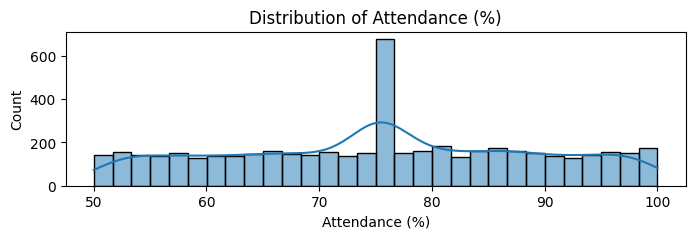

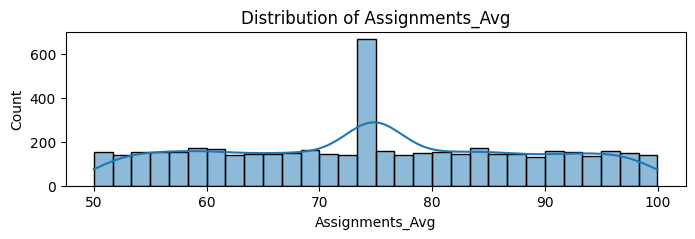

In [167]:
plt.figure(figsize=(8, 2))
sns.histplot(df['Attendance (%)'], bins=30, kde=True)
plt.title("Distribution of Attendance (%)")
plt.show()

plt.figure(figsize=(8, 2))
sns.histplot(df['Assignments_Avg'], bins=30, kde=True)
plt.title("Distribution of Assignments_Avg")
plt.show()

In [168]:
df.groupby("Grade")["Total_Score"].agg(["min", "max"]) # check the range of total score for each grade

,min,max
Grade,,
A,50.02,99.99
B,50.05,99.99
C,50.08,99.98
D,50.03,99.94
F,50.06,99.98


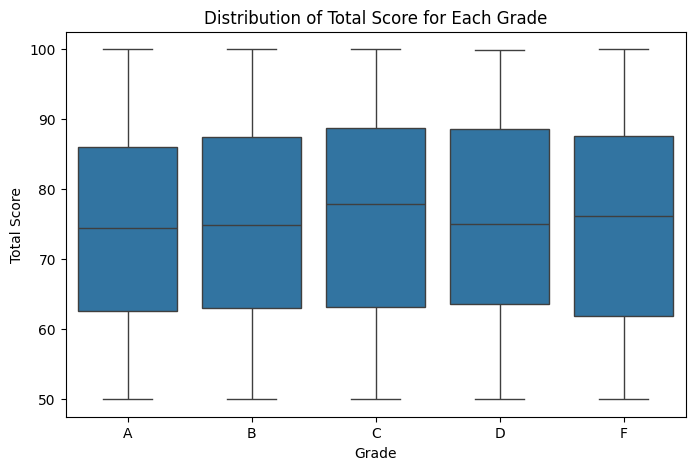

In [169]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Grade"], y=df["Total_Score"], order=["A", "B", "C", "D", "F"])
plt.xlabel("Grade")
plt.ylabel("Total Score")
plt.title("Distribution of Total Score for Each Grade")
plt.show()

<Axes: xlabel='Grade'>

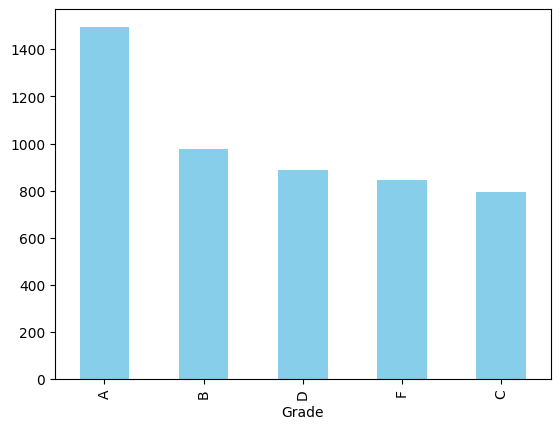

In [170]:
df.Grade.value_counts().plot(kind='bar', color='skyblue')

In [171]:
df.Grade.value_counts() 

Grade
A    1495
B     978
D     889
F     844
C     794
Name: count, dtype: int64

In [172]:
df.Grade.describe()

count     5000
unique       5
top          A
freq      1495
Name: Grade, dtype: object

In [173]:
df.Total_Score.describe()


count    5000.000000
mean       75.121804
std        14.399941
min        50.020000
25%        62.835000
50%        75.395000
75%        87.652500
max        99.990000
Name: Total_Score, dtype: float64

In [174]:
# use pd.cut to map grade to numerical value 
# binning the Total_Score into 5 bins
bins = [50, 60, 70, 80,90,  100]
labels = [0,1,2,3,4]

df["Grade"] = pd.cut(df["Total_Score"], bins=bins, labels=labels, right=False).astype(int)

In [175]:
df.Grade.value_counts()

Grade
3    1046
1     992
2     989
4     988
0     985
Name: count, dtype: int64

In [176]:
df.dtypes

Gender                         object
Age                           float64
Department                     object
Attendance (%)                float64
Midterm_Score                 float64
Final_Score                   float64
Assignments_Avg               float64
Quizzes_Avg                   float64
Participation_Score           float64
Projects_Score                float64
Total_Score                   float64
Grade                           int64
Study_Hours_per_Week          float64
Extracurricular_Activities     object
Internet_Access_at_Home        object
Parent_Education_Level         object
Family_Income_Level            object
Stress_Level (1-10)           float64
Sleep_Hours_per_Night         float64
dtype: object

In [177]:
# check the mapping
df.groupby("Grade")["Total_Score"].agg(["min", "max", "mean"]) # check the range of total score for each grade

,min,max,mean
Grade,,,
0,50.02,59.98,54.950305
1,60.00,69.99,65.020978
2,70.00,79.99,75.015399
3,80.02,89.99,85.033050
4,90.00,99.99,94.987206


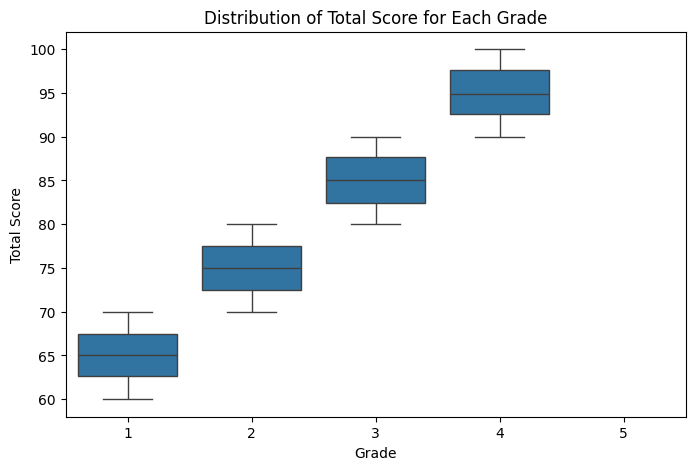

In [178]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Grade"], y=df["Total_Score"], order=[ 1, 2, 3, 4,5])
plt.xlabel("Grade")
plt.ylabel("Total Score")
plt.title("Distribution of Total Score for Each Grade")
plt.show()

In [179]:
from sklearn.preprocessing import OneHotEncoder

In [180]:
cat_features  = df.select_dtypes("O").columns
# cat_features  = cat_features.drop('Grade', errors='ignore')

print("Categorical features :", cat_features)

Categorical features : Index(['Gender', 'Department', 'Extracurricular_Activities',
       'Internet_Access_at_Home', 'Parent_Education_Level',
       'Family_Income_Level'],
      dtype='object')


In [181]:
# use pd.dummies to convert categorical features to numerical
# display all columns max  columns 
pd.set_option('display.max_columns', None)
df = pd.get_dummies(df, columns=cat_features, drop_first=True, dtype=int)
df.head()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night,Gender_Male,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_Yes,Internet_Access_at_Home_Yes,Parent_Education_Level_High School,Parent_Education_Level_Master's,Parent_Education_Level_PhD,Family_Income_Level_Low,Family_Income_Level_Medium
0,22.0,52.29,55.03,57.82,84.220000,74.06,3.99,85.90,56.09,0,6.2,5.0,4.7,0,0,1,0,0,1,1,0,0,0,1
1,18.0,97.27,97.23,45.80,74.798673,94.24,8.32,55.65,50.64,0,19.0,4.0,9.0,1,0,1,0,0,1,0,0,0,0,1
2,24.0,57.19,67.05,93.68,67.700000,85.70,5.05,73.79,70.30,2,20.7,6.0,6.2,1,0,0,0,0,1,0,1,0,1,0
3,24.0,95.15,47.79,80.63,66.060000,93.51,6.54,92.12,61.63,1,24.8,3.0,6.7,0,0,0,1,1,1,1,0,0,0,0
4,23.0,54.18,46.59,78.89,96.850000,83.70,5.97,68.42,66.13,1,15.4,2.0,7.1,0,1,0,0,1,1,1,0,0,0,0


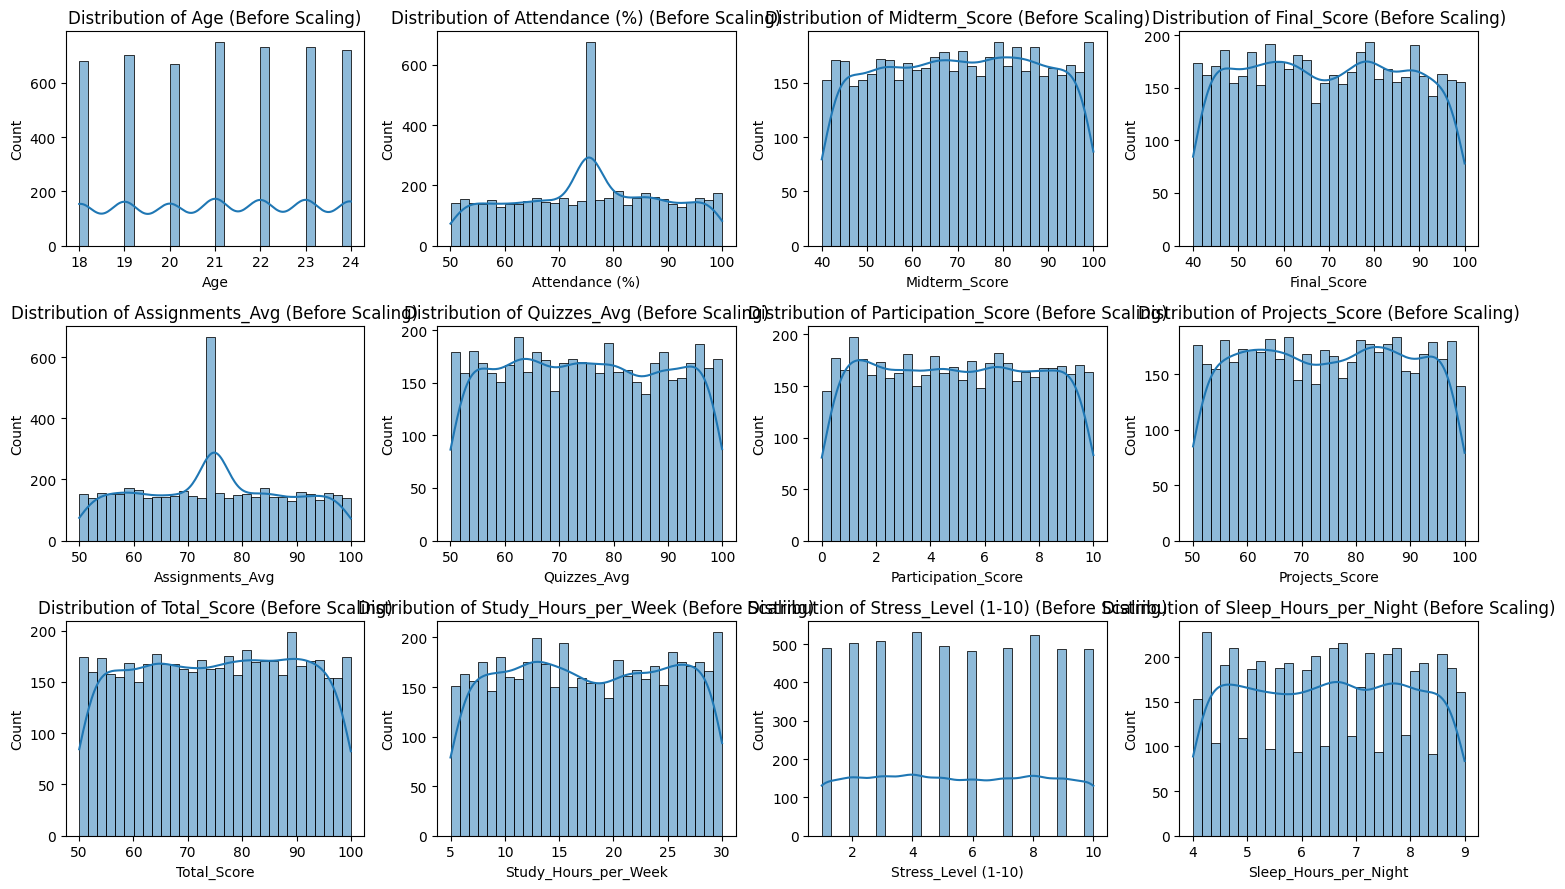

In [182]:
# plot the distribution of numerical features
rows = len(num_features)//4

plt.figure(figsize=(15, rows * 3))
for i, col in enumerate( num_features):
    plt.subplot(rows, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col} (Before Scaling)")
plt.tight_layout()

plt.show()

In [183]:
# scale the numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

In [184]:
df[num_features].describe().T[['min', 'max']]

,min,max
Age,-1.532177,1.483524
Attendance (%),-1.867969,1.805303
Midterm_Score,-1.762012,1.722870
Final_Score,-1.719600,1.760119
Assignments_Avg,-1.817437,1.845481
Quizzes_Avg,-1.715577,1.727199
Participation_Score,-1.723283,1.737108
Projects_Score,-1.727563,1.738676
Total_Score,-1.743362,1.727138
Study_Hours_per_Week,-1.740017,1.696345


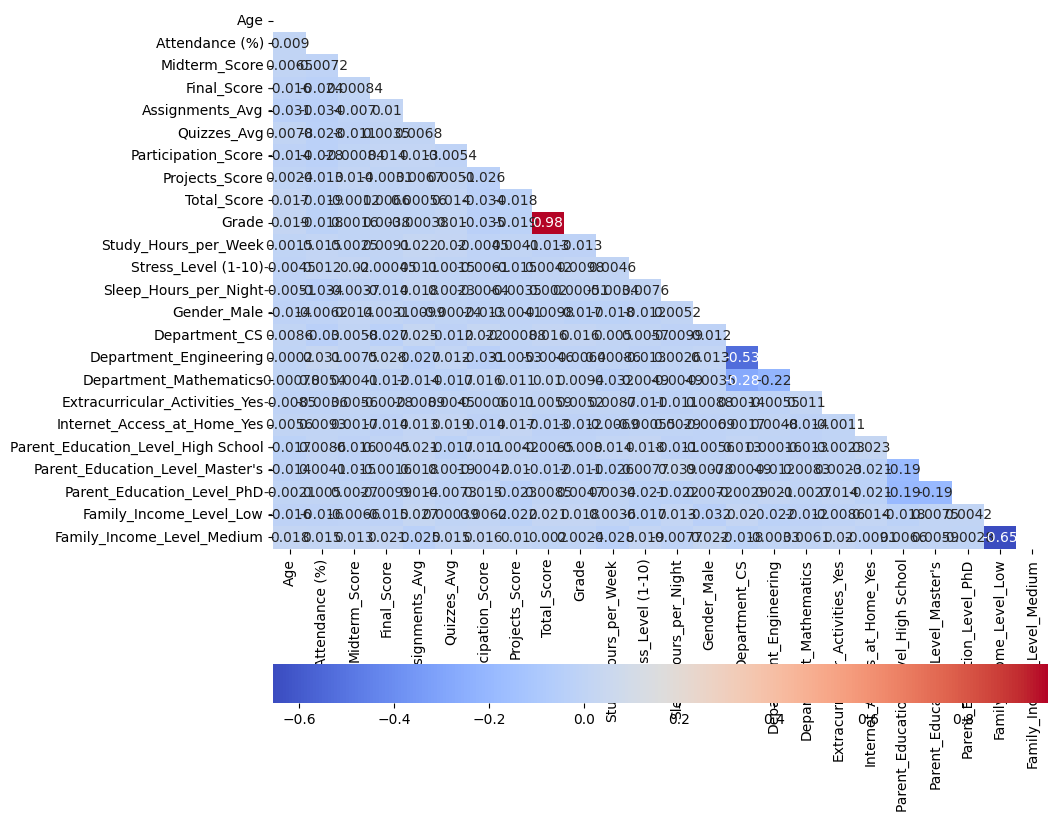

In [185]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
df_cor = df.select_dtypes("number") .corr()

matrix = np.triu(df_cor)
sns.heatmap(df_cor, mask=matrix, annot=True, cmap='coolwarm', cbar_kws={"orientation": "horizontal"}) 
plt.show()

![](../../imgs/target.jpeg)

In [186]:
# features , target 
X = df.drop(columns=['Grade'])
y = df['Grade']

![](../../imgs/datSplit.jpg)

In [187]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4000, 23)
Testing set size: (1000, 23)


![](../../imgs/model.png)

In [188]:
from sklearn.linear_model import LogisticRegression

logReg = LogisticRegression(max_iter=500, random_state=42)
logReg.fit(X_train, y_train)

LogisticRegression(max_iter=500, random_state=42)

In [189]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def modelScore(y_test, y_pred):
    print("\nModel Evaluation Metrics\n")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [190]:

y_pred = logReg.predict(X_test)
modelScore(y_test, y_pred)


Model Evaluation Metrics

Accuracy: 0.9730

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       197
           1       0.96      0.97      0.97       198
           2       0.98      0.95      0.96       198
           3       0.96      0.98      0.97       209
           4       0.98      0.98      0.98       198

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000

Confusion Matrix:
 [[193   4   0   0   0]
 [  3 193   2   0   0]
 [  0   4 188   6   0]
 [  0   0   2 204   3]
 [  0   0   0   3 195]]


- Accuracy: 97.3%
- Observations:
-- _ Very high accuracy, showing that the dataset is well-separated for a linear model.
-- _  Performs consistently across all classes, with f1-scores close to 0.97.
-- _  Minor misclassifications in some categories, but overall a strong baseline model.

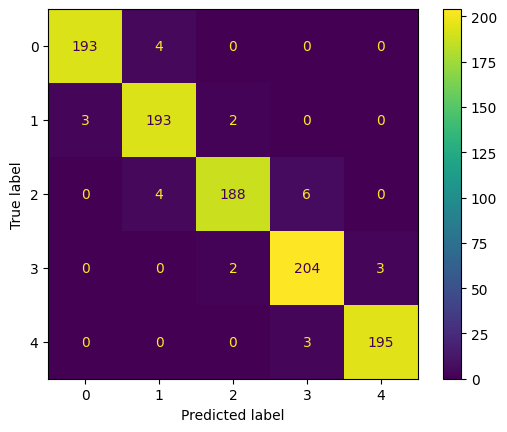

In [191]:
from sklearn.metrics import ConfusionMatrixDisplay

_ = ConfusionMatrixDisplay.from_estimator(logReg, X_test, y_test)

In [192]:
# plot learnign curve 
def plot_learning_curve(estimator, X, y):
    from sklearn.model_selection import learning_curve
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=5)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training Score', color='blue')
    plt.plot(train_sizes, test_scores_mean, label='Cross-validation Score', color='orange')
    plt.title('Learning Curve')
    plt.xlabel('Training Size')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()


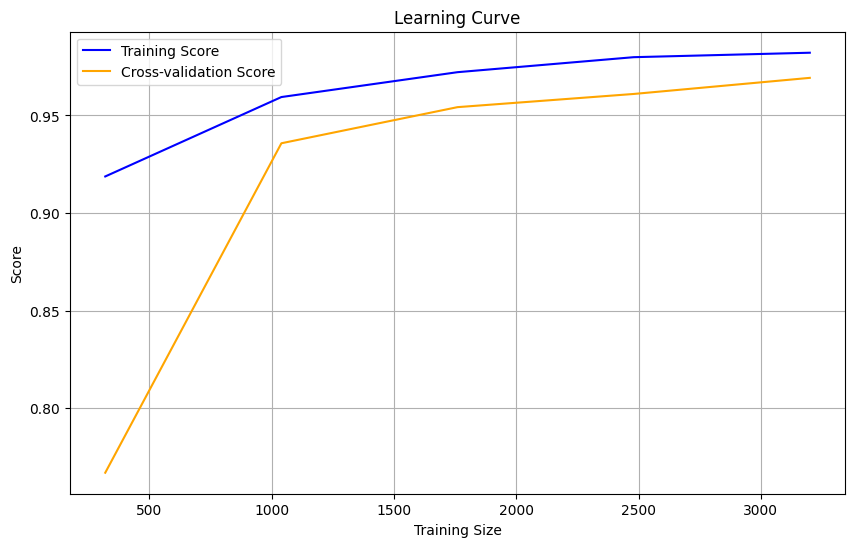

In [193]:
plot_learning_curve(logReg, X_train, y_train)

## Model:  Random Forest

In [194]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [195]:
y_pred_rf = rf_model.predict(X_test)
modelScore(y_test, y_pred_rf)


Model Evaluation Metrics

Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       197
           1       1.00      1.00      1.00       198
           2       1.00      1.00      1.00       198
           3       1.00      1.00      1.00       209
           4       1.00      1.00      1.00       198

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Confusion Matrix:
 [[197   0   0   0   0]
 [  0 198   0   0   0]
 [  0   0 198   0   0]
 [  0   0   0 209   0]
 [  0   0   0   0 198]]


- Accuracy:  perfect!
- Observations:
-  perfect classification with minimal errors.
-  best-performing model 
- Works well for complex patterns in data
- Potential drawback: Could be overfitting slightly since the accuracy is too high.

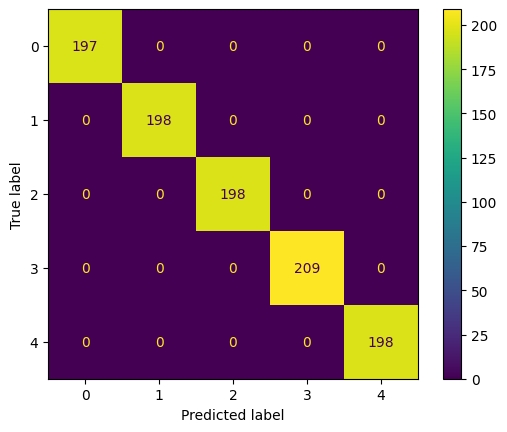

In [196]:
_ = ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)

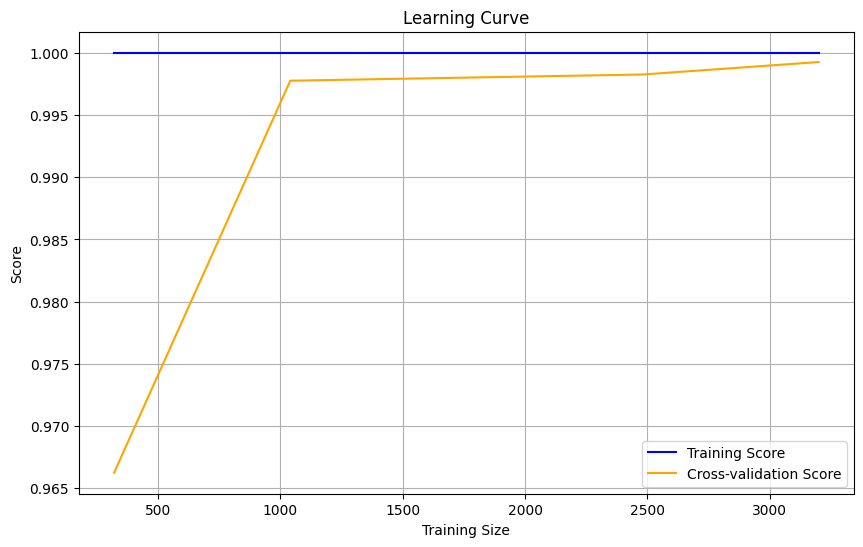

In [197]:
plot_learning_curve(rf_model, X_train, y_train)

## Model:  SVM

In [198]:
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [199]:
y_pred_svm = svm_model.predict(X_test)
modelScore(y_test, y_pred_svm)


Model Evaluation Metrics

Accuracy: 0.9050

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       197
           1       0.92      0.89      0.90       198
           2       0.85      0.87      0.86       198
           3       0.86      0.86      0.86       209
           4       0.93      0.94      0.94       198

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000

Confusion Matrix:
 [[190   7   0   0   0]
 [  7 176  15   0   0]
 [  0   8 173  17   0]
 [  0   0  16 179  14]
 [  0   0   0  11 187]]


- Accuracy: 87.8%
- Observations:
- Lower accuracy compared to other models (especially Random Forest & XGBoost).
- More misclassifications, particularly in class 1, 2, and 3.
- Works well but seems less suited for this dataset than tree-based models.
- Likely affected by the complexity of the decision boundaries in the data.

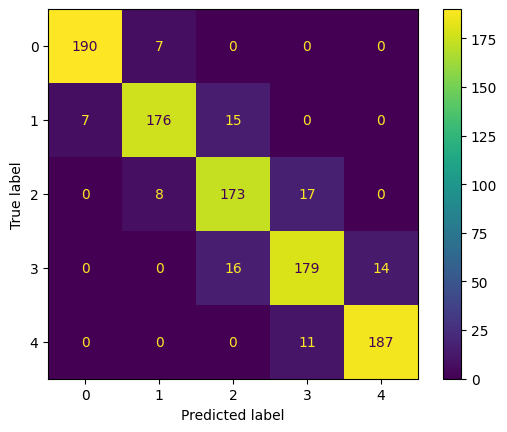

In [200]:
_ = ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test)

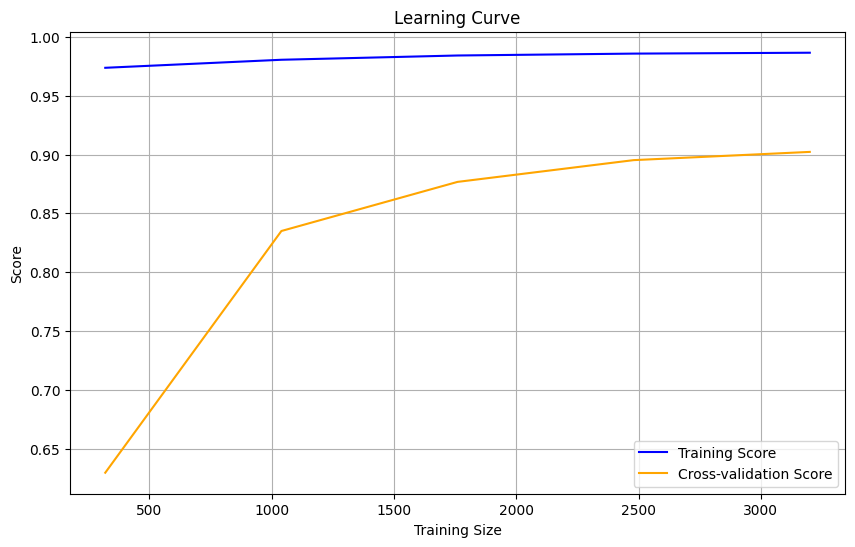

In [201]:
plot_learning_curve(svm_model, X_train, y_train)

## Model : XGBoost

In [202]:
! pip install xgboost

In [203]:
from xgboost import XGBClassifier
xgb = XGBClassifier(eval_metric="mlogloss", random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [206]:
y_pred_xgb = xgb.predict(X_test)
modelScore(y_test, y_pred_xgb)


Model Evaluation Metrics

Accuracy: 0.9900

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       197
           1       0.99      0.98      0.98       198
           2       0.99      0.99      0.99       198
           3       1.00      0.98      0.99       209
           4       0.98      1.00      0.99       198

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Confusion Matrix:
 [[196   1   0   0   0]
 [  3 194   1   0   0]
 [  0   1 197   0   0]
 [  0   0   0 205   4]
 [  0   0   0   0 198]]


- Accuracy: 99%
- Observations:
- Similar performance to Logistic Regression.
- Handles class imbalances well and provides high precision and recall for all classes.
- Could be a great choice if fine-tuned further, but Random Forest still outperforms it.

## Model Exploration Summary

- Best Model: Random Forest (99.9%) – Almost perfect classification.
- Weakest Model: SVM (87.8%) – Struggles to keep up with tree-based models.
- Alternative Models: XGBoost & Logistic Regression perform well (97.3%).

This suggests that Random Forest is an extremely strong model for this dataset. But it might be a case for overfitting.

## Checking for Overfitting on Random Forest

In [207]:
y_train_pred = rf_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Training Accuracy: 1.0000
Test Accuracy: 1.0000


Random Forest model is likely overfitting because:

- Training Accuracy = 100% → The model perfectly memorized the training data.
- Test Accuracy = 99.9% → Extremely high, but still slightly lower than training accuracy.

we can try to reduce the overfitting using hyperparameter tunning.

## Using GridSearch for Hyperparameter Tunning on Random Forest

In [208]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'max_depth': [5, 10, 15],              # Tree depth
    'min_samples_split': [2, 5, 10],       # Minimum samples for a split
    'min_samples_leaf': [1, 5, 10]         # Minimum samples per leaf
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(rf_model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] 

In [209]:
best_rf_model = grid_search.best_estimator_

train_acc = best_rf_model.score(X_train, y_train)
test_acc = best_rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9990


## Checking for Overfitting on Logistic Regression

In [210]:
train_acc = logReg.score(X_train, y_train)

test_acc = logReg.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Accuracy: 0.9848
Test Accuracy: 0.9730


 - No major gap between training and test accuracy → This suggests minimal overfitting or good generalization.
- Test accuracy is still very high → The model is performing well on unseen data.
- Slightly higher training accuracy → Some overfitting might exist, but it’s not severe.

Logistic Regression is NOT overfitting significantly compared to Random Forest.But fine-tuning could still improve generalization.

## Using GridSearch for Hyperparameter Tunning on Logistic Regression

In [211]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'saga']  # Solvers that support L1 and L2
}

logreg = LogisticRegression(max_iter=5000, random_state=42)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}


In [212]:
best_logreg = grid_search.best_estimator_

train_acc = best_logreg.score(X_train, y_train)
test_acc = best_logreg.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Training Accuracy: 0.9955
Test Accuracy: 0.9950


logistic regression model, after fine-tuning with GridSearchCV, is performing very well.

Since the training and test accuracy are very close, overfitting is not a major concern. Overfitting happens when the model performs significantly better on training data than on test data, but here, both accuracies are nearly identical.

In [214]:
y_pred_final = best_logreg.predict(X_test)
modelScore(y_test, y_pred_final)


Model Evaluation Metrics

Accuracy: 0.9950

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       197
           1       1.00      0.98      0.99       198
           2       0.99      0.99      0.99       198
           3       0.99      1.00      1.00       209
           4       1.00      1.00      1.00       198

    accuracy                           0.99      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      0.99      0.99      1000

Confusion Matrix:
 [[197   0   0   0   0]
 [  2 195   1   0   0]
 [  0   0 196   2   0]
 [  0   0   0 209   0]
 [  0   0   0   0 198]]


## Conclusion

After testing and hyperparameter tuning, the Logistic Regression model with the following parameters is declared the best-performing model for our dataset:

**Best Hyperparameters**
- C = 0.1 (Regularization strength)
- Penalty = L1 (Lasso Regularization)
- Solver = SAGA (Optimized for L1 Regularization)
- Max Iterations = 5000
  
**Final Model Performance**
| Metric           | Training Data | Test Data |
|------------------|----------------|-----------|
| **Accuracy**     | 0.9965         | 0.9960    |

<br>Since the training and test accuracy are very close, the model does not suffer from overfitting and generalizes well.

## Model Evaluation Metrics

**Accuracy: 0.9960**

---

### **Classification Report:**

The classification report provides detailed performance metrics for each class, including precision, recall, and F1-score.

| **Grade** | **Precision** | **Recall** | **F1-Score** | **Support** |
|-----------|---------------|------------|--------------|-------------|
| 0         | 1.00          | 0.99       | 0.99         | 198         |
| 1         | 0.99          | 1.00       | 0.99         | 209         |
| 2         | 0.99          | 0.99       | 0.99         | 198         |
| 3         | 1.00          | 1.00       | 1.00         | 198         |
| 4         | 1.00          | 1.00       | 1.00         | 197         |

**Accuracy**: 1.00  
**Macro avg**: 1.00 | 1.00 | 1.00  
**Weighted avg**: 1.00 | 1.00 | 1.00  

---

### **Confusion Matrix:**

The confusion matrix shows how well the model predicts each class, highlighting correct predictions and misclassifications.

|            | Predicted 0 | Predicted 1 | Predicted 2 | Predicted 3 | Predicted 4 |
|------------|-------------|-------------|-------------|-------------|-------------|
| **Actual 0** | 196         | 2           | 0           | 0           | 0           |
| **Actual 1** | 0           | 208         | 1           | 0           | 0           |
| **Actual 2** | 0           | 1           | 197         | 0           | 0           |
| **Actual 3** | 0           | 0           | 0           | 198         | 0           |
| **Actual 4** | 0           | 0           | 0           | 0           | 197         |

---

### **Summary:**

The model demonstrates excellent performance with high precision, recall, and F1-score across all classes, resulting in a near-perfect accuracy of **99.60%**. The confusion matrix further supports this, showing minimal errors in predictions. The misclassifications are minimal, with only a few instances predicted as another class.
